# Data Visualization with Matplotlib and Seaborn

## Exercise 1: Understanding Data Visualization

### Why is data visualization important in data analysis?

Data visualization transforms raw numbers into graphical representations that the human brain can process much faster than tables of text. Its importance rests on several pillars:

- **Pattern recognition**: Charts and graphs make trends, clusters, and outliers immediately visible, whereas the same information buried in rows of a spreadsheet might go unnoticed for hours.
- **Communication**: A well-chosen visualization conveys a finding to a non-technical audience in seconds. Executives, clients, and colleagues who cannot read statistical output can still understand a bar chart.
- **Hypothesis generation**: Exploratory plots often reveal unexpected structure in data (a bimodal distribution, a non-linear relationship, a seasonal pattern) that guides further analysis.
- **Quality control**: Plotting raw data is one of the fastest ways to spot data-entry errors, missing values, or implausible values before they corrupt downstream results.
- **Decision support**: Dashboards and visual reports allow decision-makers to monitor KPIs and react to changes in real time.

### Purpose of a line graph

A line graph connects individual data points with straight segments, making it the natural choice for showing how a continuous quantity changes over an ordered dimension — usually time. Its main purposes are:

- **Showing trends**: the upward or downward direction of a line communicates momentum at a glance (e.g., rising sales, falling temperatures).
- **Comparing multiple series**: several lines on the same axes make it easy to compare the evolution of different categories (e.g., revenue by product line over quarters).
- **Highlighting inflection points**: sudden changes in slope draw the eye to moments worth investigating (a spike in website traffic, a drop in stock price).
- **Conveying continuity**: unlike a bar chart, a line implies that values exist between the measured points, which is appropriate for truly continuous phenomena such as sensor readings or physiological measurements.

## Exercise 2: Line Plot — Temperature Variation over a Week

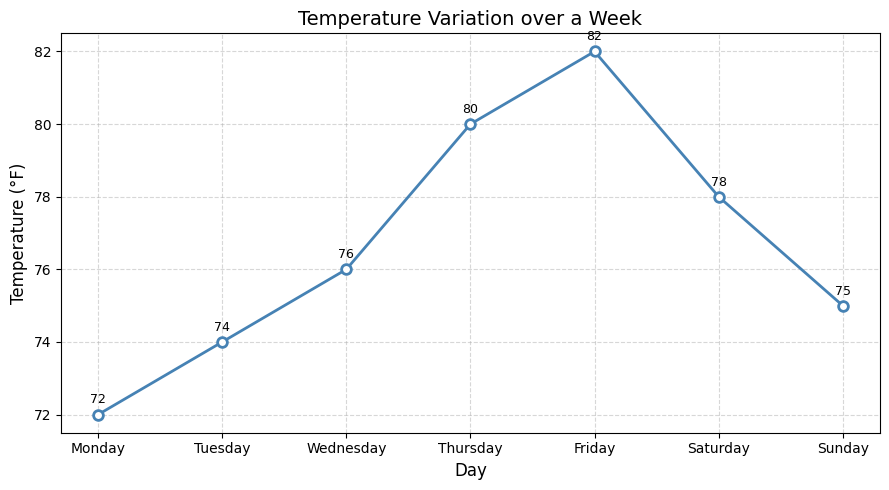

In [1]:
import matplotlib.pyplot as plt

days         = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
temperatures = [72, 74, 76, 80, 82, 78, 75]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(days, temperatures, marker='o', linewidth=2, color='steelblue',
        markersize=7, markerfacecolor='white', markeredgewidth=2)

ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Temperature (°F)', fontsize=12)
ax.set_title('Temperature Variation over a Week', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)

# annotate each point with its value
for i, (day, temp) in enumerate(zip(days, temperatures)):
    ax.annotate(str(temp), xy=(i, temp), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Exercise 3: Bar Chart — Monthly Sales

In [ ]:
import matplotlib.pyplot as plt

months = ['January', 'February', 'March', 'April', 'May']
sales  = [5000, 5500, 6200, 7000, 7500]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(months, sales, color='#4C72B0', edgecolor='white', width=0.6)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Sales Amount ($)', fontsize=12)
ax.set_title('Monthly Sales for a Retail Store', fontsize=14)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(0, max(sales) * 1.15)

# label each bar with its value
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'${height:,}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Setup — Dataset Download (Exercises 4, 5, 6)

In [ ]:
import io
import zipfile
import requests
import pandas as pd
import numpy as np

url = ("https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/"
       "Week%203/W3D1%20-%20Data%20Visualization/Student%20Mental%20health.zip")

try:
    response = requests.get(url, timeout=10)
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        csv_name = [n for n in z.namelist() if n.endswith('.csv')][0]
        with z.open(csv_name) as f:
            df = pd.read_csv(f)
    print("Loaded from URL.")
except Exception:
    # Inline fallback — representative sample matching the Kaggle dataset structure
    print("URL unavailable. Using built-in fallback data.")
    np.random.seed(42)
    n = 101
    genders   = np.random.choice(['Male', 'Female'], n, p=[0.35, 0.65])
    ages      = np.random.randint(18, 25, n)
    cgpa_bins = ['3.50 - 4.00', '3.00 - 3.49', '2.50 - 2.99', '2.00 - 2.49', '0 - 1.99']
    cgpa      = np.random.choice(cgpa_bins, n, p=[0.30, 0.35, 0.20, 0.10, 0.05])
    yes_no    = lambda p: np.random.choice(['Yes', 'No'], n, p=[p, 1-p])
    df = pd.DataFrame({
        'Timestamp'                              : pd.date_range('2021-01-01', periods=n, freq='D'),
        'Choose your gender'                     : genders,
        'Age'                                    : ages,
        'What is your course?'                   : np.random.choice(['Engineering', 'BIT', 'Law', 'Islamic education'], n),
        'Your current year of Study'             : np.random.choice(['Year 1','Year 2','Year 3','Year 4'], n),
        'What is your CGPA?'                     : cgpa,
        'Marital status'                         : np.random.choice(['No', 'Yes'], n, p=[0.9, 0.1]),
        'Do you have Depression?'                : yes_no(0.35),
        'Do you have Anxiety?'                   : yes_no(0.40),
        'Do you have Panic attack?'              : yes_no(0.30),
        'Did you seek any specialist for a treatment?': yes_no(0.20),
    })

# Normalise column names (strip whitespace)
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df.head()

In [ ]:
# Quick overview of the dataset
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

## Exercise 4: Histogram — Distribution of CGPA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify the correct CGPA column name
cgpa_col = [c for c in df.columns if 'CGPA' in c or 'cgpa' in c.lower()][0]
print("CGPA column:", cgpa_col)
print(df[cgpa_col].value_counts())

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# CGPA is categorical (ranges), so we use countplot instead of histplot
order = sorted(df[cgpa_col].dropna().unique())
sns.countplot(data=df, x=cgpa_col, order=order,
              color='#4C72B0', edgecolor='white', ax=ax)

ax.set_title("Distribution of Students\' CGPA", fontsize=14)
ax.set_xlabel('CGPA Range', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# add count labels on each bar
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 4),
                textcoords='offset points')

plt.tight_layout()
plt.show()

In [ ]:
# Alternative: histplot on numeric CGPA midpoints for a true histogram feel
cgpa_midpoints = {
    '3.50 - 4.00': 3.75, '3.00 - 3.49': 3.25,
    '2.50 - 2.99': 2.75, '2.00 - 2.49': 2.25, '0 - 1.99': 1.00
}
df['CGPA_numeric'] = df[cgpa_col].map(cgpa_midpoints)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x='CGPA_numeric', bins=10, color='#55A868',
             edgecolor='white', kde=True, ax=ax)
ax.set_title("Distribution of Students\' CGPA (numeric midpoints)", fontsize=14)
ax.set_xlabel('CGPA (midpoint)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Exercise 5: Bar Plot — Anxiety Levels Across Genders

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify relevant columns
anxiety_col = [c for c in df.columns if 'Anxiety' in c][0]
gender_col  = [c for c in df.columns if 'gender' in c.lower()][0]
print("Anxiety column:", anxiety_col)
print("Gender column :", gender_col)
print(df.groupby([gender_col, anxiety_col]).size())

In [ ]:
# Compute proportion of 'Yes' per gender
anxiety_pct = (
    df.groupby([gender_col, anxiety_col])
    .size()
    .reset_index(name='Count')
)
totals = df.groupby(gender_col).size().reset_index(name='Total')
anxiety_pct = anxiety_pct.merge(totals, on=gender_col)
anxiety_pct['Proportion'] = anxiety_pct['Count'] / anxiety_pct['Total']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: stacked count bar chart ---
pivot = anxiety_pct.pivot(index=gender_col, columns=anxiety_col, values='Count').fillna(0)
pivot.plot(kind='bar', ax=axes[0], color=['#DD8452', '#4C72B0'],
           edgecolor='white', width=0.5)
axes[0].set_title('Anxiety Count by Gender', fontsize=13)
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Number of Students', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Anxiety')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.4)

# --- Right: proportion bar chart (only 'Yes') ---
yes_only = anxiety_pct[anxiety_pct[anxiety_col] == 'Yes']
sns.barplot(data=yes_only, x=gender_col, y='Proportion',
            palette={'Male': '#4C72B0', 'Female': '#DD8452'},
            edgecolor='white', ax=axes[1])
axes[1].set_title('Proportion of Students with Anxiety by Gender', fontsize=13)
axes[1].set_xlabel('Gender', fontsize=11)
axes[1].set_ylabel('Proportion with Anxiety', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].grid(True, axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Anxiety Levels Across Different Genders', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Exercise 6: Scatter Plot — Age vs Panic Attacks

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify the panic attack column
panic_col = [c for c in df.columns if 'Panic' in c or 'panic' in c][0]
print("Panic attack column:", panic_col)
print(df[panic_col].value_counts())

In [ ]:
# Convert Yes/No to 1/0
df['Panic_Numeric'] = df[panic_col].map({'Yes': 1, 'No': 0})

# Add jitter to the binary y-axis for readability
np.random.seed(0)
df['Panic_Jitter'] = df['Panic_Numeric'] + np.random.uniform(-0.07, 0.07, len(df))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: basic scatter with jitter, coloured by panic outcome ---
palette = {1: '#C44E52', 0: '#4C72B0'}
for val, label, color in [(1, 'Yes', '#C44E52'), (0, 'No', '#4C72B0')]:
    sub = df[df['Panic_Numeric'] == val]
    axes[0].scatter(sub['Age'], sub['Panic_Jitter'],
                    label=label, alpha=0.55, s=40, color=color, edgecolors='white', linewidths=0.5)

axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['No', 'Yes'])
axes[0].set_title('Age vs Panic Attacks (jittered)', fontsize=13)
axes[0].set_xlabel('Age', fontsize=11)
axes[0].set_ylabel('Panic Attack', fontsize=11)
axes[0].legend(title='Panic Attack')
axes[0].grid(True, linestyle='--', alpha=0.4)

# --- Right: proportion of panic attacks per age group ---
age_panic = df.groupby('Age')['Panic_Numeric'].mean().reset_index()
age_panic.columns = ['Age', 'Proportion_Panic']

sns.barplot(data=age_panic, x='Age', y='Proportion_Panic',
            color='#C44E52', edgecolor='white', ax=axes[1])
axes[1].set_title('Proportion of Students with Panic Attacks by Age', fontsize=13)
axes[1].set_xlabel('Age', fontsize=11)
axes[1].set_ylabel('Proportion with Panic Attacks', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].grid(True, axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Relationship Between Age and Panic Attacks', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# --- Seaborn scatterplot as required by the exercise ---
fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='Age',
    y='Panic_Jitter',
    hue=panic_col,
    palette={'Yes': '#C44E52', 'No': '#4C72B0'},
    style=panic_col,
    markers={'Yes': 'X', 'No': 'o'},
    s=70,
    alpha=0.65,
    ax=ax
)

ax.set_yticks([0, 1])
ax.set_yticklabels(['No (0)', 'Yes (1)'])
ax.set_title('Age vs Panic Attacks — Seaborn Scatter Plot', fontsize=14)
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Panic Attack (numeric)', fontsize=12)
ax.legend(title='Panic Attack')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()